# Literature Validation Set Overview

## 1. Purpose
This notebook summarizes and validates the public **Literature Validation Set** associated with the repository. 
It provides a safe, transparent, and reproducible way to inspect the physical domain boundaries and consistency of the experimental data used for testing.

**Important:** This notebook does **not** reproduce the training of the final machine learning model from the paper, as that model relies on proprietary data which cannot be shared publicly.

## 2. Open in Colab
You can run this notebook interactively in Google Colab without any local setup:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/misael-tup/reduced-input-pvt-ml/blob/main/notebooks/literature_validation_overview.ipynb)


In [1]:
# If running in Google Colab or without the pvt_ml package, uncomment and run:
# !pip install git+https://github.com/misael-tup/reduced-input-pvt-ml.git

## 3. Load public data
We load the publicly available CSV files containing the filtered experimental points and the literature sources metadata.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import IPython.display as display_lib

try:
    from pvt_ml.literature import (
        validate_literature_validation_dataframe,
        validate_literature_sources_dataframe,
        summarize_literature_dataframe
    )
except ImportError:
    print('Please install the pvt_ml package first.')

# Load data locally or from GitHub if not found
val_path = '../data/literature_validation.csv'
src_path = '../data/literature_sources.csv'

if not os.path.exists(val_path):
    val_path = 'https://raw.githubusercontent.com/misael-tup/reduced-input-pvt-ml/main/data/literature_validation.csv'
    src_path = 'https://raw.githubusercontent.com/misael-tup/reduced-input-pvt-ml/main/data/literature_sources.csv'

df_val = pd.read_csv(val_path)
df_src = pd.read_csv(src_path)

print('Data loaded successfully.')

Data loaded successfully.


## 4. Validate schema
We run the strict programmatic validation to ensure the datasets comply with the public schema and contain no unauthorized or proprietary columns.

In [3]:
# Validate data
validate_literature_validation_dataframe(df_val, require_reduced_columns=True)
validate_literature_sources_dataframe(df_src)

print('Validation passed: No proprietary or unauthorized columns detected.')

Validation passed: No proprietary or unauthorized columns detected.


## 5. Dataset summary
We calculate aggregate metrics for the literature validation set.

In [4]:
# Summary metrics
summary = summarize_literature_dataframe(df_val)

print(f"Number of pressure points: {summary['n_points']}")
print(f"Number of fluids: {summary['n_fluids']}")
print(f"Number of sources: {summary['n_sources']}")
print(f"Fluid IDs range: L2-L21")
print(f"Columns: {list(df_val.columns)}")

Number of pressure points: 184
Number of fluids: 20
Number of sources: 18
Fluid IDs range: L2-L21
Columns: ['literature_fluid_id', 'source_key', 'P', 'Pb', 'T_C', 'Rsb_scf_stb', 'Rs_scf_stb', 'P_over_Pb', 'Rsr']


## 6. Verify reduced variables
We verify that the reduced variables `P_over_Pb` and `Rsr` are correctly calculated according to their fundamental physical definitions.

In [5]:
# Verify reduced pressure
p_reduced_correct = np.allclose(df_val['P_over_Pb'], df_val['P'] / df_val['Pb'])
if p_reduced_correct:
    print('Reduced pressure check: OK')

# Verify reduced Rs
rs_reduced_correct = np.allclose(df_val['Rsr'], df_val['Rs_scf_stb'] / df_val['Rsb_scf_stb'])
if rs_reduced_correct:
    print('Reduced Rs check: OK')

Reduced pressure check: OK
Reduced Rs check: OK


## 7. Source-level summary
We aggregate the dataset by source reference to show the distribution of data points across the literature.

In [6]:
# Group by source key
source_summary = df_val.groupby('source_key').agg(
    n_fluids=('literature_fluid_id', 'nunique'),
    n_points=('P', 'count')
).reset_index()

display_lib.display(source_summary)

,source_key,n_fluids,n_points
0,abidini_2018,1,6
1,al_marhoun_2003,1,12
2,alagoa_2023,1,8
3,christensen_1999,1,7
4,elias_trevisan_2016,1,9
5,igwe_ujile_2015,1,7
6,klein_1959,2,20
7,labedi_1982,1,11
8,mccain_2002,1,13
9,nnabuo_2014,1,6


## 8. Public visualization
We visualize the experimental literature data in the dimensionless domain (Reduced Pressure vs Reduced Rs).

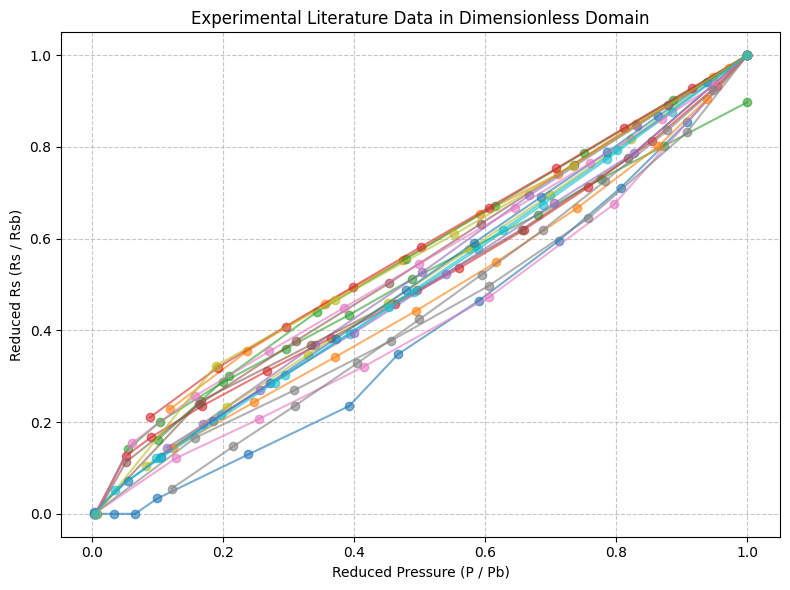

In [7]:
plt.figure(figsize=(8, 6))

for fluid_id in df_val['literature_fluid_id'].unique():
    fluid_data = df_val[df_val['literature_fluid_id'] == fluid_id].sort_values('P_over_Pb')
    plt.plot(fluid_data['P_over_Pb'], fluid_data['Rsr'], marker='o', alpha=0.6, label=fluid_id if len(df_val['literature_fluid_id'].unique()) <= 20 else '')

plt.title('Experimental Literature Data in Dimensionless Domain')
plt.xlabel('Reduced Pressure (P / Pb)')
plt.ylabel('Reduced Rs (Rs / Rsb)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 9. What this notebook does not do
To respect confidentiality agreements, this public repository and notebook:
- **Do not train** the final Hybrid-PT machine learning model.
- **Do not load** any proprietary, pre-trained `.joblib` or `.pkl` models.
- **Do not reproduce** the complete numerical metrics or parity plots of the paper.
- **Do not contain** the Development Set, Blind External Validation Set, or Additional Mexican PVT validation set.
- **Do not contain** original Mexican PVT reports or well/field names.